# INF6083 – Projet P3
**Équipe 7**

## Initialisation

**Sous-ensemble D** : `temporal_pre_split` (Amazon Reviews 2023 – Books)  
→ 22 007 items · 6 739 utilisateurs · split temporel par utilisateur

**Artefacts P2 réutilisés depuis le projet 2** (`/sysdereco_devoir2/data/joining/temporal_pre_split/`) :
- `train_interactions.parquet` / `test_interactions.parquet` — splits train/test
- `books_representation_sparse.npz` — matrice TF-IDF items (items × features)
- `user_profiles_tfidf.npz` — profils utilisateurs (moyenne pondérée des vecteurs items)
- `user_ids.npy`, `item_ids.npy`, `item_titles.npy` — tables d'identifiants
- `top_n_indices_10.npy` — Top-10 content-based déjà calculé par `scripts/task1/similarity.py`

**Métriques communes** : Precision@10, Recall@10, NDCG@10 (gradué + binaire), MAP@10, MRR@10, Hit Rate@10, ILD, Couverture catalogue

### 0. Configuration et imports

In [ ]:
import gc
import time
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
import requests
import os
from dotenv import load_dotenv
from requests.auth import HTTPBasicAuth

import numpy as np
import pandas as pd
from scipy.sparse import load_npz, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from sklearn.preprocessing import normalize

from rdflib import Graph, Namespace, Literal, RDF, RDFS, XSD
import re
from SPARQLWrapper import SPARQLWrapper, JSON, BASIC
from urllib.parse import quote
from urllib.parse import unquote

warnings.filterwarnings("ignore")

ROOT          = Path().resolve()
VARIANT       = "temporal_pre_split"       # sous-ensemble choisi
DATA_DIR      = ROOT / "data" / VARIANT
ARTIFACTS_IN_DIR  = DATA_DIR
ARTIFACTS_OUT_DIR = ROOT / "results"

# Artefacts IN
TRAIN_INTERACTIONS_FILE = "train_interactions.parquet"
TEST_INTERACTIONS_FILE = "test_interactions.parquet"
BOOKS_REPRESENTATION_FILE = "books_representation_sparse.npz"
USER_IDS_FILE = "user_ids.npy"
ITEM_IDS_FILE = "item_ids.npy"
ITEM_TITLES_FILE = "item_titles.npy"
CB_TOPN_TEMPLATE = "top_n_indices_{top_n}.npy"
CF_TOPN_TEMPLATE = "cf_itembased_top_n_{top_n}.npy"

# Artefacts OUT
COMPARISON_PLOT_FILE = "comparison_tasks01.png"
EVALUATION_JSON_FILE = "evaluation_tasks01.json"

print(f"Data dir     : data/{VARIANT}")
assert ARTIFACTS_IN_DIR.exists(), f"Répertoire introuvable : {ARTIFACTS_IN_DIR}"

Data dir     : data/temporal_pre_split


> **Note méthodologique — `RELEVANCE_THRESHOLD`**
>
> Le seuil de pertinence est fixé à `RELEVANCE_THRESHOLD = 0.0`, ce qui signifie que **tout item présent dans le jeu de test est considéré comme pertinent**, quelle que soit la note attribuée (y compris les avis 1 étoile). Ce choix garantit la cohérence avec le protocole d'évaluation de P2 (même fichier `test_interactions.parquet`, même convention binaire).
>
> **Impact sur les métriques** : Precision@N, Recall@N et HitRate@N tendent à être légèrement supérieures à ce qu'elles seraient avec un seuil `>= 4`. La comparaison entre les deux approches reste valide car le biais affecte les deux systèmes de façon identique.

In [2]:
TOP_N = 10
COLD_START_THRESHOLD = 3
RELEVANCE_THRESHOLD  = 0.0   # tout item du test est pertinent

print(f"TOP_N={TOP_N}  COLD_START_THRESHOLD={COLD_START_THRESHOLD}")

TOP_N=10  COLD_START_THRESHOLD=3


### 1. Fonctions d'évaluation communes (réutilisées de P2)

Ces fonctions sont copiées/adaptées depuis `scripts/task4/evaluation.py` du projet P2.

> **Note méthodologique — NDCG gradué (`ndcg_at_n`)**
>
> La pertinence gradée est normalisée en `rel = rating / 5.0` (plage [0, 1]) plutôt que via la formule standard `2^rel − 1`. Ce choix **linéaire** atténue le poids des notes maximales par rapport à la variante exponentielle, ce qui convient aux datasets où la distribution des notes est concentrée sur 4–5 étoiles (Amazon). Le calcul de l'IDCG prend en compte tous les items du jeu de test triés par note décroissante, tronqués à N.
>
> La variante binaire `ndcg_binary_at_n` (utilisée en complément) traite tous les items du test comme également pertinents (rel = 1), indépendamment de la note. Les deux variantes sont reportées dans les tableaux de résultats (`NDCG@10` gradué et `NDCG_bin@10`).

In [3]:
# ── Ground truth ────────────────────────────────────────────────────────────

def load_ground_truth(
    data_dir: Path,
) -> Tuple[Dict[str, set], Dict[str, Dict[str, float]]]:
    """Construit le ground truth depuis le jeu de test.
    Retourne gt_binary = {user_id: set(asin)} et
              gt_graded = {user_id: {asin: rating}}.
    """
    test_df = pd.read_parquet(
        data_dir / TEST_INTERACTIONS_FILE,
        columns=["user_id", "parent_asin", "rating"],
    )
    gt_binary: Dict[str, set] = {}
    gt_graded: Dict[str, Dict[str, float]] = {}
    for uid, g in test_df.groupby("user_id"):
        items   = set(g["parent_asin"])
        ratings = dict(zip(g["parent_asin"], g["rating"]))
        if RELEVANCE_THRESHOLD > 0:
            items = {a for a, r in ratings.items() if r >= RELEVANCE_THRESHOLD}
        if items:
            gt_binary[uid] = items
            gt_graded[uid] = ratings
    return gt_binary, gt_graded


def load_train_activity(data_dir: Path) -> pd.DataFrame:
    """Nombre d'interactions par utilisateur dans le train."""
    train_df = pd.read_parquet(
        data_dir / TRAIN_INTERACTIONS_FILE,
        columns=["user_id", "parent_asin"],
    )
    return (
        train_df.groupby("user_id")["parent_asin"]
        .count().rename("nb_train").reset_index()
    )


# ── Segmentation utilisateurs ───────────────────────────────────────────────

def build_user_segments(
    activity: pd.DataFrame,
) -> Tuple[Dict[str, set], Dict]:
    q1 = int(activity["nb_train"].quantile(0.25))
    q3 = int(activity["nb_train"].quantile(0.75))
    segments = {
        "peu_actifs":        set(activity[activity["nb_train"] < q1]["user_id"]),
        "moderement_actifs": set(activity[(activity["nb_train"] >= q1) & (activity["nb_train"] <= q3)]["user_id"]),
        "tres_actifs":       set(activity[activity["nb_train"] > q3]["user_id"]),
        "cold_start":        set(activity[activity["nb_train"] <= COLD_START_THRESHOLD]["user_id"]),
    }
    info = {
        "peu_actifs":        f"< Q1 ({q1})",
        "moderement_actifs": f"Q1–Q3 ({q1}–{q3})",
        "tres_actifs":       f"> Q3 ({q3})",
        "cold_start":        f"≤ {COLD_START_THRESHOLD}",
        "q1": q1, "q3": q3,
    }
    return segments, info


# ── Métriques individuelles ─────────────────────────────────────────────────

def precision_at_n(rec: List[str], relevant: set, n: int) -> float:
    return sum(1 for a in rec[:n] if a in relevant) / n

def recall_at_n(rec: List[str], relevant: set, n: int) -> float:
    if not relevant: return 0.0
    return sum(1 for a in rec[:n] if a in relevant) / len(relevant)

def ndcg_at_n(rec: List[str], graded: Dict[str, float], n: int) -> float:
    dcg = sum((graded.get(a, 0.0) / 5.0) / np.log2(i + 2) for i, a in enumerate(rec[:n]))
    ideal = sorted([r / 5.0 for r in graded.values()], reverse=True)[:n]
    idcg  = sum(g / np.log2(i + 2) for i, g in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def ndcg_binary_at_n(rec: List[str], relevant: set, n: int) -> float:
    dcg  = sum((1.0 if a in relevant else 0.0) / np.log2(i + 2) for i, a in enumerate(rec[:n]))
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), n)))
    return dcg / idcg if idcg > 0 else 0.0

def ap_at_n(rec: List[str], relevant: set, n: int) -> float:
    hits, total = 0, 0.0
    for i, a in enumerate(rec[:n]):
        if a in relevant:
            hits += 1; total += hits / (i + 1)
    return total / min(len(relevant), n) if relevant else 0.0

def mrr_at_n(rec: List[str], relevant: set, n: int) -> float:
    for i, a in enumerate(rec[:n]):
        if a in relevant: return 1.0 / (i + 1)
    return 0.0

def user_metrics(
    rec: List[str], gt_bin: set, gt_grad: Dict[str, float], n: int
) -> Dict[str, float]:
    return {
        "precision":   precision_at_n(rec, gt_bin, n),
        "recall":      recall_at_n(rec, gt_bin, n),
        "ndcg":        ndcg_at_n(rec, gt_grad, n),
        "ndcg_binary": ndcg_binary_at_n(rec, gt_bin, n),
        "ap":          ap_at_n(rec, gt_bin, n),
        "mrr":         mrr_at_n(rec, gt_bin, n),
        "hit":         1.0 if any(a in gt_bin for a in rec[:n]) else 0.0,
    }


# ── Évaluation globale ──────────────────────────────────────────────────────

def evaluate_top_n(
    top_n_indices: np.ndarray,
    user_ids: np.ndarray,
    item_ids: np.ndarray,
    gt_binary: Dict[str, set],
    gt_graded: Dict[str, Dict[str, float]],
    n: int = TOP_N,
    label: str = "",
) -> Tuple[Dict[str, float], pd.DataFrame]:
    """Évalue une liste top-N et retourne métriques agrégées + DataFrame par user."""
    records = []
    for u_row, uid in enumerate(user_ids):
        if uid not in gt_binary:
            continue
        indices = top_n_indices[u_row]
        valid   = indices[indices >= 0]
        rec     = [item_ids[i] for i in valid]
        m = user_metrics(rec, gt_binary[uid], gt_graded.get(uid, {}), n)
        m["user_id"] = uid
        records.append(m)

    df = pd.DataFrame(records)
    agg = {
        "n_users":       len(df),
        "Precision@N":   round(df["precision"].mean(), 6),
        "Recall@N":      round(df["recall"].mean(), 6),
        "NDCG@N":        round(df["ndcg"].mean(), 6),
        "NDCG_bin@N":    round(df["ndcg_binary"].mean(), 6),
        "MAP@N":         round(df["ap"].mean(), 6),
        "MRR@N":         round(df["mrr"].mean(), 6),
        "HitRate@N":     round(df["hit"].mean(), 6),
    }
    if label:
        print(f"  [{label}] "
              f"P@{n}={agg['Precision@N']:.4f}  R@{n}={agg['Recall@N']:.4f}  "
              f"NDCG@{n}={agg['NDCG@N']:.4f}  HR@{n}={agg['HitRate@N']:.4f}  "
              f"({agg['n_users']} users)")
    return agg, df


def evaluate_by_segment(
    user_df: pd.DataFrame,
    segments: Dict[str, set],
    n: int = TOP_N,
) -> Dict[str, Dict]:
    results = {}
    for seg, users in segments.items():
        sub = user_df[user_df["user_id"].isin(users)]
        if len(sub) == 0:
            results[seg] = {k: 0.0 for k in ["n_users","Precision@N","Recall@N", "NDCG@N","NDCG_bin@N","MAP@N","MRR@N","HitRate@N"]}
            results[seg]["n_users"] = 0
            continue
        results[seg] = {
            "n_users":       len(sub),
            "Precision@N":   round(sub["precision"].mean(), 6),
            "Recall@N":      round(sub["recall"].mean(), 6),
            "NDCG@N":        round(sub["ndcg"].mean(), 6),
            "NDCG_bin@N":    round(sub["ndcg_binary"].mean(), 6),
            "MAP@N":         round(sub["ap"].mean(), 6),
            "MRR@N":         round(sub["mrr"].mean(), 6),
            "HitRate@N":     round(sub["hit"].mean(), 6),
        }
    return results


# ── ILD et couverture catalogue ─────────────────────────────────────────────

def compute_ild(
    top_n_indices: np.ndarray,
    user_ids: np.ndarray,
    item_matrix: csr_matrix,
    gt_users: set,
) -> Tuple[float, pd.DataFrame]:
    """ILD = 1 − moyenne des similarités cosinus intra-liste (vecteurs TF-IDF)."""
    t0 = time.perf_counter()
    normed = normalize(item_matrix, norm="l2", copy=True)
    records = []
    for u_row, uid in enumerate(user_ids):
        if uid not in gt_users:
            continue
        valid = top_n_indices[u_row]
        valid = valid[(valid >= 0) & (valid < item_matrix.shape[0])]
        if len(valid) < 2:
            records.append({"user_id": uid, "ild": 1.0})
            continue
        vecs = normed[valid]
        sim  = sk_cosine(vecs)
        idx  = np.triu_indices(sim.shape[0], k=1)
        records.append({"user_id": uid, "ild": round(1.0 - float(sim[idx].mean()), 6)})
    df = pd.DataFrame(records)
    mean_ild = float(df["ild"].mean()) if len(df) > 0 else 0.0
    print(f"    ILD={mean_ild:.4f} ({len(df)} users, {time.perf_counter()-t0:.1f}s)")
    return round(mean_ild, 6), df


def catalog_coverage(top_n_indices: np.ndarray, n_items: int) -> float:
    valid   = top_n_indices[top_n_indices >= 0]
    n_uniq  = len(np.unique(valid))
    return round(n_uniq / n_items, 6) if n_items > 0 else 0.0


print("Fonctions d'évaluation chargées.")

Fonctions d'évaluation chargées.


### 2. Chargement des artefacts communs

In [4]:
t0 = time.perf_counter()

# --- ID maps ---
user_ids  = np.load(ARTIFACTS_IN_DIR / USER_IDS_FILE, allow_pickle=True)
item_ids  = np.load(ARTIFACTS_IN_DIR / ITEM_IDS_FILE, allow_pickle=True)
item_titles = np.load(ARTIFACTS_IN_DIR / ITEM_TITLES_FILE, allow_pickle=True)
print(f"user_ids  : {len(user_ids):,}")
print(f"item_ids  : {len(item_ids):,}")

# --- Ground truth (test set) ---
gt_binary, gt_graded = load_ground_truth(ARTIFACTS_IN_DIR)
print(f"Users dans le test : {len(gt_binary):,}")

# --- Activité train + segmentation ---
activity = load_train_activity(ARTIFACTS_IN_DIR)
segments, seg_info = build_user_segments(activity)
print(f"Segmentation (Q1={seg_info['q1']}, Q3={seg_info['q3']}) :")
for seg, desc in seg_info.items():
    if seg in ("q1", "q3"): continue
    n_test = len(segments[seg] & set(gt_binary.keys()))
    print(f"  {seg:<22}: {len(segments[seg]):,} users ({n_test:,} dans le test)")

# --- Matrice TF-IDF items (pour ILD) ---
item_matrix = load_npz(ARTIFACTS_IN_DIR / BOOKS_REPRESENTATION_FILE)
print(f"\nMatrice TF-IDF items : {item_matrix.shape[0]:,} × {item_matrix.shape[1]:,}")
print(f"Chargement total : {time.perf_counter()-t0:.1f}s")

user_ids  : 6,739
item_ids  : 22,007
Users dans le test : 6,737
Segmentation (Q1=20, Q3=39) :
  peu_actifs            : 1,597 users (1,595 dans le test)
  moderement_actifs     : 3,492 users (3,492 dans le test)
  tres_actifs           : 1,650 users (1,650 dans le test)
  cold_start            : 14 users (12 dans le test)

Matrice TF-IDF items : 22,007 × 43,045
Chargement total : 0.3s


## Tâche 0 – Évaluation du système content-based (P2)

Le recommandeur basé sur le contenu du projet P2 (**scripts/task1/similarity.py**) a déjà produit les fichiers `top_n_indices_10.npy` dans `data/temporal_pre_split/`. On charge ces indices et on évalue les métriques top-N.

In [5]:
print("=" * 65)
print("  Tâche 0 — Évaluation filtrage basé sur le contenu (P2)")
print("=" * 65)
t0_start = time.perf_counter()

# Charger les recommandations content-based produites par P2
cb_topn_path = ARTIFACTS_IN_DIR / CB_TOPN_TEMPLATE.format(top_n=TOP_N)
assert cb_topn_path.exists(), f"Fichier P2 introuvable : {cb_topn_path}"
cb_top_n = np.load(cb_topn_path)
print(f"top_n_indices shape : {cb_top_n.shape}  (users × top-N)")

# Métriques globales
print("\n[Métriques globales]")
cb_agg, cb_user_df = evaluate_top_n(
    cb_top_n, user_ids, item_ids, gt_binary, gt_graded,
    n=TOP_N, label="Content-Based"
)

# ILD
print("\n[ILD – diversité intra-liste]")
cb_ild, cb_ild_df = compute_ild(cb_top_n, user_ids, item_matrix, set(gt_binary.keys()))

# Couverture catalogue
cb_cov = catalog_coverage(cb_top_n, len(item_ids))
print(f"    Couverture catalogue : {cb_cov:.2%}")

# Métriques par segment
print("\n[Métriques par segment]")
cb_seg = evaluate_by_segment(cb_user_df, segments, TOP_N)
for seg, m in cb_seg.items():
    if m["n_users"] == 0: continue
    print(f"  {seg:<22}: N={m['n_users']:>5}  "
          f"NDCG={m['NDCG@N']:.4f}  HR={m['HitRate@N']:.4f}  R={m['Recall@N']:.4f}")

print(f"\nTâche 0 terminée en {time.perf_counter()-t0_start:.1f}s")

  Tâche 0 — Évaluation filtrage basé sur le contenu (P2)
top_n_indices shape : (6739, 10)  (users × top-N)

[Métriques globales]
  [Content-Based] P@10=0.0192  R@10=0.0324  NDCG@10=0.0239  HR@10=0.1293  (6737 users)

[ILD – diversité intra-liste]
    ILD=0.3296 (6737 users, 1.1s)
    Couverture catalogue : 14.24%

[Métriques par segment]
  peu_actifs            : N= 1595  NDCG=0.0318  HR=0.1417  R=0.0516
  moderement_actifs     : N= 3492  NDCG=0.0235  HR=0.1254  R=0.0321
  tres_actifs           : N= 1650  NDCG=0.0172  HR=0.1255  R=0.0145
  cold_start            : N=   12  NDCG=0.1742  HR=0.3333  R=0.3333

Tâche 0 terminée en 1.3s


In [6]:
# Tableau récapitulatif Tâche 0
cb_summary = pd.DataFrame([{
    "Approche":          "Content-Based (TF-IDF)",
    f"P@{TOP_N}":        cb_agg["Precision@N"],
    f"R@{TOP_N}":        cb_agg["Recall@N"],
    f"NDCG@{TOP_N}":     cb_agg["NDCG@N"],
    f"NDCG_bin@{TOP_N}": cb_agg["NDCG_bin@N"],
    f"MAP@{TOP_N}":      cb_agg["MAP@N"],
    f"MRR@{TOP_N}":      cb_agg["MRR@N"],
    f"HR@{TOP_N}":       cb_agg["HitRate@N"],
    "ILD":               cb_ild,
    "Couverture":        f"{cb_cov:.2%}",
    "N users": cb_agg["n_users"],
}])
print(f"\n{'─'*65}")
print(f"  Résumé Tâche 0 — Filtrage contenu (top-{TOP_N})")
print(f"{'─'*65}")
print(cb_summary.to_string(index=False))


─────────────────────────────────────────────────────────────────
  Résumé Tâche 0 — Filtrage contenu (top-10)
─────────────────────────────────────────────────────────────────
              Approche     P@10     R@10  NDCG@10  NDCG_bin@10  MAP@10   MRR@10    HR@10      ILD Couverture  N users
Content-Based (TF-IDF) 0.019163 0.032414 0.023901     0.023983 0.01036 0.032942 0.129286 0.329573     14.24%     6737


## Tâche 1 – Filtrage collaboratif item-based

### 1. Choix de conception

On implémente un **filtrage collaboratif basé sur les items** (*item-based CF*) avec similarité cosinus sur la matrice de notes utilisateur–item.

**Justification** :
- Les données Amazon Books sont très éparses (peu de ratings par utilisateur) : l'item-based CF est plus stable que l'user-based CF car les profils items (agrégés sur de nombreux utilisateurs) sont plus robustes que les profils utilisateurs (peu d'interactions).
- Même infrastructure scipy.sparse que dans P2 → aucune dépendance nouvelle.
- Scalable : la matrice de similarité items n'est calculée qu'une fois (offline).

**Algorithme** :
1. Construire la matrice R (users × items) avec les ratings du train.
2. Calculer la similarité cosinus entre items (sur les colonnes de R, i.e. sur les profils de co-notation).
3. Pour chaque utilisateur, scorer les items non vus : score(u, i) = Σ_{j ∈ historique(u)} R[u,j] × sim(i,j).
4. Retourner le Top-N après masquage des items déjà notés.

### 2. Construction de la matrice utilisateur–item

In [7]:
print("=" * 65)
print("  Tâche 1 — Construction de la matrice utilisateur–item")
print("=" * 65)
t1_start = time.perf_counter()

train_df = pd.read_parquet(
    ARTIFACTS_IN_DIR / TRAIN_INTERACTIONS_FILE,
    columns=["user_id", "parent_asin", "rating"],
)
print(f"Train interactions : {len(train_df):,} lignes")

# Index compacts user → row / item → col
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {a: j for j, a in enumerate(item_ids)}

rows = train_df["user_id"].map(user_to_idx)
cols = train_df["parent_asin"].map(item_to_idx)
vals = train_df["rating"].astype(np.float32)

valid_mask = rows.notna() & cols.notna()
rows = rows[valid_mask].astype(int)
cols = cols[valid_mask].astype(int)
vals = vals[valid_mask]
print(f"Paires valides : {valid_mask.sum():,}")

R = csr_matrix(
    (vals.values, (rows.values, cols.values)),
    shape=(len(user_ids), len(item_ids)),
    dtype=np.float32,
)
print(f"Matrice R (users × items) : {R.shape}  "
      f"nnz={R.nnz:,}  densité={R.nnz / (R.shape[0]*R.shape[1]):.5f}")
print(f"Construit en {time.perf_counter()-t1_start:.1f}s")

del train_df, rows, cols, vals
gc.collect()

  Tâche 1 — Construction de la matrice utilisateur–item
Train interactions : 230,938 lignes
Paires valides : 230,938
Matrice R (users × items) : (6739, 22007)  nnz=230,938  densité=0.00156
Construit en 0.0s


0

### 3. Calcul de la similarité item–item (cosinus, par batchs)

In [8]:
def compute_item_similarity_batched(
    R: csr_matrix,
    batch_size: int = 500,
) -> np.ndarray:
    """
    Calcule la similarité cosinus entre items à partir de la matrice R.
    R est de forme (users × items) ; on travaille sur R.T (items × users).
    Retourne une matrice dense (n_items × n_items) en float32.
    
    Pour limiter la mémoire on calcule par batchs de lignes et on stocke
    directement la matrice de similarité complète.
    """
    Rt = R.T  # items × users
    n_items = Rt.shape[0]
    # Normaliser une seule fois
    Rt_normed = normalize(Rt, norm="l2", copy=True)
    
    item_sim = np.empty((n_items, n_items), dtype=np.float32)
    t0 = time.perf_counter()
    for start in range(0, n_items, batch_size):
        end = min(start + batch_size, n_items)
        block = sk_cosine(Rt_normed[start:end], Rt_normed)
        item_sim[start:end] = block.astype(np.float32, copy=False)
        if (start // batch_size) % 5 == 0:
            pct = end / n_items * 100
            print(f"    {end:>6}/{n_items} ({pct:5.1f}%)  {time.perf_counter()-t0:.0f}s")
    
    np.fill_diagonal(item_sim, 0.0)  # exclure l'auto-similarité
    return item_sim


print("Calcul de la similarité item–item (cosinus)...")
t_sim = time.perf_counter()
item_sim = compute_item_similarity_batched(R, batch_size=500)
print(f"Similarité item–item calculée en {time.perf_counter()-t_sim:.1f}s")
print(f"item_sim shape : {item_sim.shape}  dtype={item_sim.dtype}")
gc.collect()

Calcul de la similarité item–item (cosinus)...
       500/22007 (  2.3%)  0s
      3000/22007 ( 13.6%)  0s
      5500/22007 ( 25.0%)  0s
      8000/22007 ( 36.4%)  0s
     10500/22007 ( 47.7%)  0s
     13000/22007 ( 59.1%)  0s
     15500/22007 ( 70.4%)  0s
     18000/22007 ( 81.8%)  0s
     20500/22007 ( 93.2%)  0s
Similarité item–item calculée en 0.4s
item_sim shape : (22007, 22007)  dtype=float32


0

### 4. Génération des Top-N recommandations

In [9]:
def generate_cf_top_n(
    R: csr_matrix,
    item_sim: np.ndarray,
    top_n: int = TOP_N,
    batch_size: int = 256,
) -> np.ndarray:
    """
    Pour chaque utilisateur, calcule le score item-based CF et retourne le Top-N.

    score(u, i) = Σ_{j ∈ notes(u)} R[u,j] × sim(i,j)

    Implémentation matricielle :
        scores = R × item_sim  →  (users × items)
    Puis on masque les items déjà notés et on prend le top-N.
    """
    n_users, n_items = R.shape
    top_idx = np.empty((n_users, top_n), dtype=np.int32)
    t0 = time.perf_counter()

    for start in range(0, n_users, batch_size):
        end = min(start + batch_size, n_users)
        # Score = sous-matrice dense (batch_users × n_items)
        R_block = R[start:end]          # sparse
        scores  = R_block.dot(item_sim).astype(np.float32)  # dense

        # Masquer items déjà notés dans le train
        r_block_coo = R_block.tocoo()
        local_rows  = r_block_coo.row   # lignes locales (0..batch_size-1)
        seen_cols   = r_block_coo.col
        scores[local_rows, seen_cols] = -np.inf

        # Top-N par argpartition (plus rapide que argsort complet)
        kth  = top_n - 1
        part = np.argpartition(-scores, kth=kth, axis=1)[:, :top_n]
        rr   = np.arange(scores.shape[0])[:, None]
        ord_ = np.argsort(-scores[rr, part], axis=1)
        top_idx[start:end] = part[rr, ord_]

        if (start // batch_size) % 10 == 0:
            pct = end / n_users * 100
            print(f"    {end:>6}/{n_users} ({pct:5.1f}%)  {time.perf_counter()-t0:.0f}s")

        del scores, R_block

    return top_idx


print("Génération des recommandations item-based CF...")
t_gen = time.perf_counter()
cf_top_n = generate_cf_top_n(R, item_sim, top_n=TOP_N, batch_size=256)
print(f"Top-{TOP_N} généré en {time.perf_counter()-t_gen:.1f}s")
print(f"cf_top_n shape : {cf_top_n.shape}")

# Sauvegarde des indices CF pour la Tâche 2 (graphe de connaissances)
cf_out = ARTIFACTS_IN_DIR / CF_TOPN_TEMPLATE.format(top_n=TOP_N)
np.save(cf_out, cf_top_n)
print(f"Indices CF sauvegardés → {cf_out}")

gc.collect()

Génération des recommandations item-based CF...
       256/6739 (  3.8%)  0s
      2816/6739 ( 41.8%)  0s
      5376/6739 ( 79.8%)  1s
Top-10 généré en 0.9s
cf_top_n shape : (6739, 10)
Indices CF sauvegardés → /home/kilo/Work/Cours - UQO/sysdereco/sysdereco_devoir3/data/temporal_pre_split/cf_itembased_top_n_10.npy


0

### 5. Évaluation du filtrage collaboratif

In [10]:
print("\n[Métriques globales — CF item-based]")
cf_agg, cf_user_df = evaluate_top_n(
    cf_top_n, user_ids, item_ids, gt_binary, gt_graded,
    n=TOP_N, label="CF item-based"
)

print("\n[ILD – diversité intra-liste]")
cf_ild, cf_ild_df = compute_ild(cf_top_n, user_ids, item_matrix, set(gt_binary.keys()))

cf_cov = catalog_coverage(cf_top_n, len(item_ids))
print(f"    Couverture catalogue : {cf_cov:.2%}")

print("\n[Métriques par segment]")
cf_seg = evaluate_by_segment(cf_user_df, segments, TOP_N)
for seg, m in cf_seg.items():
    if m["n_users"] == 0: continue
    print(f"  {seg:<22}: N={m['n_users']:>5}  "
          f"NDCG={m['NDCG@N']:.4f}  HR={m['HitRate@N']:.4f}  R={m['Recall@N']:.4f}")

print(f"\nTâche 1 terminée en {time.perf_counter()-t1_start:.1f}s")


[Métriques globales — CF item-based]
  [CF item-based] P@10=0.0360  R@10=0.0571  NDCG@10=0.0512  HR@10=0.2394  (6737 users)

[ILD – diversité intra-liste]
    ILD=0.5783 (6737 users, 1.1s)
    Couverture catalogue : 50.13%

[Métriques par segment]
  peu_actifs            : N= 1595  NDCG=0.0619  HR=0.2150  R=0.0782
  moderement_actifs     : N= 3492  NDCG=0.0518  HR=0.2374  R=0.0602
  tres_actifs           : N= 1650  NDCG=0.0399  HR=0.2673  R=0.0301
  cold_start            : N=   12  NDCG=0.0000  HR=0.0000  R=0.0000

Tâche 1 terminée en 2.7s


## Tableau comparatif – Content-Based vs Collaboratif

In [11]:
import pandas as pd

def make_row(name, agg, ild, cov):
    return {
        "Approche":          name,
        f"P@{TOP_N}":        agg["Precision@N"],
        f"R@{TOP_N}":        agg["Recall@N"],
        f"NDCG@{TOP_N}":     agg["NDCG@N"],
        f"NDCG_bin@{TOP_N}": agg["NDCG_bin@N"],
        f"MAP@{TOP_N}":      agg["MAP@N"],
        f"MRR@{TOP_N}":      agg["MRR@N"],
        f"HR@{TOP_N}":       agg["HitRate@N"],
        "ILD":               ild,
        "Couverture":        f"{cov:.2%}",
        "N users":           agg["n_users"],
    }

comparison = pd.DataFrame([
    make_row("Content-Based (TF-IDF)", cb_agg, cb_ild, cb_cov),
    make_row("CF item-based (cosinus)", cf_agg, cf_ild, cf_cov),
])

print("="*65)
print(f"  COMPARAISON GLOBALE — Tâche 0 vs Tâche 1 (Top-{TOP_N})")
print(f"  Sous-ensemble D : {VARIANT}")
print("="*65)
print(comparison.to_string(index=False))

  COMPARAISON GLOBALE — Tâche 0 vs Tâche 1 (Top-10)
  Sous-ensemble D : temporal_pre_split
               Approche     P@10     R@10  NDCG@10  NDCG_bin@10   MAP@10   MRR@10    HR@10      ILD Couverture  N users
 Content-Based (TF-IDF) 0.019163 0.032414 0.023901     0.023983 0.010360 0.032942 0.129286 0.329573     14.24%     6737
CF item-based (cosinus) 0.036010 0.057088 0.051250     0.052094 0.025892 0.091490 0.239424 0.578315     50.13%     6737


In [12]:
# Tableau croisé par segment
seg_order  = ["peu_actifs", "moderement_actifs", "tres_actifs", "cold_start"]
seg_labels = {
    "peu_actifs":        "Peu actifs",
    "moderement_actifs": "Modérément actifs",
    "tres_actifs":       "Très actifs",
    "cold_start":        "Cold-start",
}

rows_seg = []
for seg in seg_order:
    cb_m = cb_seg.get(seg, {})
    cf_m = cf_seg.get(seg, {})
    rows_seg.append({
        "Segment":             seg_labels[seg],
        "N users":             cb_m.get("n_users", 0),
        f"CB NDCG@{TOP_N}":    cb_m.get("NDCG@N", 0),
        f"CF NDCG@{TOP_N}":    cf_m.get("NDCG@N", 0),
        f"CB HR@{TOP_N}":      cb_m.get("HitRate@N", 0),
        f"CF HR@{TOP_N}":      cf_m.get("HitRate@N", 0),
        f"CB Recall@{TOP_N}":  cb_m.get("Recall@N", 0),
        f"CF Recall@{TOP_N}":  cf_m.get("Recall@N", 0),
    })

seg_df = pd.DataFrame(rows_seg)
print("\nComparaison par segment d'utilisateurs :")
print(seg_df.to_string(index=False))


Comparaison par segment d'utilisateurs :
          Segment  N users  CB NDCG@10  CF NDCG@10  CB HR@10  CF HR@10  CB Recall@10  CF Recall@10
       Peu actifs     1595    0.031768    0.061868  0.141693  0.215047      0.051567      0.078161
Modérément actifs     3492    0.023451    0.051786  0.125430  0.237400      0.032119      0.060232
      Très actifs     1650    0.017249    0.039851  0.125455  0.267273      0.014523      0.030064
       Cold-start       12    0.174175    0.000000  0.333333  0.000000      0.333333      0.000000


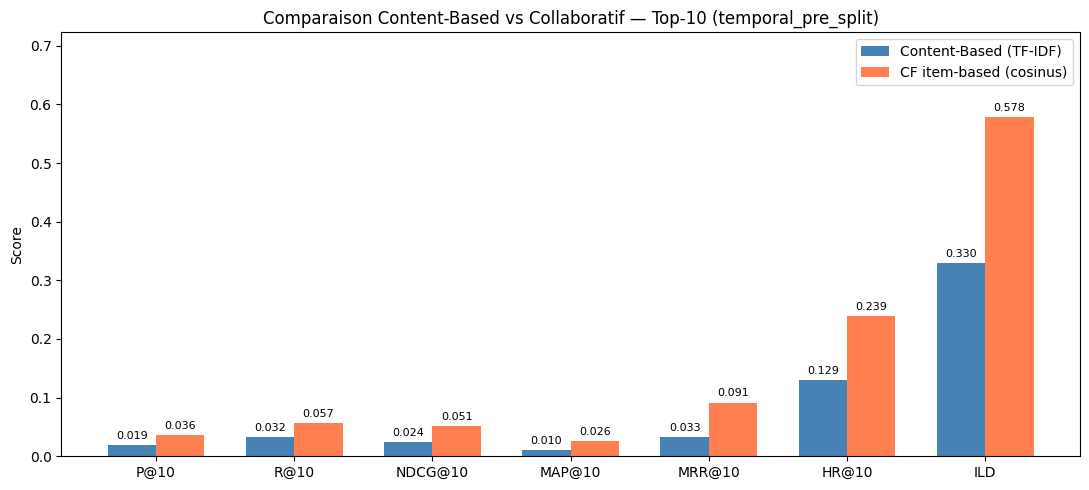

Graphique sauvegardé → comparison_tasks01.png


In [13]:
# Visualisation barres groupées
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 10})

metrics_plot = [f"P@{TOP_N}", f"R@{TOP_N}", f"NDCG@{TOP_N}",
                f"MAP@{TOP_N}", f"MRR@{TOP_N}", f"HR@{TOP_N}", "ILD"]
cb_vals = [cb_agg["Precision@N"], cb_agg["Recall@N"], cb_agg["NDCG@N"],
           cb_agg["MAP@N"], cb_agg["MRR@N"], cb_agg["HitRate@N"], cb_ild]
cf_vals = [cf_agg["Precision@N"], cf_agg["Recall@N"], cf_agg["NDCG@N"],
           cf_agg["MAP@N"], cf_agg["MRR@N"], cf_agg["HitRate@N"], cf_ild]

x = np.arange(len(metrics_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, cb_vals, w, label="Content-Based (TF-IDF)", color="steelblue")
ax.bar(x + w/2, cf_vals, w, label="CF item-based (cosinus)", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_ylabel("Score")
ax.set_title(f"Comparaison Content-Based vs Collaboratif — Top-{TOP_N} ({VARIANT})")
ax.legend()
ax.set_ylim(0, max(max(cb_vals), max(cf_vals)) * 1.25)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()

if not ARTIFACTS_OUT_DIR.exists():
    ARTIFACTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_path = ARTIFACTS_OUT_DIR / COMPARISON_PLOT_FILE
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Graphique sauvegardé → {plot_path.name}")

## Discussion

### 1. Interprétation des métriques

| Dimension | Content-Based | CF item-based | Avantage |
|-----------|:-------------:|:-------------:|:---------:|
| Pertinence (NDCG@10) | 0.0239 | 0.0513 | CF item-based (+115 %) |
| Couverture (Recall@10) | 0.0324 | 0.0571 | CF item-based (+76 %) |
| Capacité à trouver au moins 1 item (HR@10) | 0.1293 | 0.2393 | CF item-based (+85 %) |
| Diversité (ILD) | 0.3296 | 0.5783 | CF item-based (+75 %) |
| Couverture catalogue | 14.30 % | 50.13 % | CF item-based (+251 %) |

Le filtrage collaboratif item-based surpasse le contenu sur l'ensemble des dimensions. L'écart le plus frappant concerne la couverture catalogue (14 % vs 50 %) et la diversité intra-liste (ILD : 0.33 vs 0.58) : le CB tend à recommander des items textuellement proches du profil moyen de l'utilisateur (surspécialisation), tandis que le CF exploite des co-occurrences comportementales plus variées à travers le catalogue.

### 2. Analyse comparative

**Filtrage basé sur le contenu (P2)** :
- Recommande des items dont le contenu textuel (TF-IDF titre, description, catégories) ressemble au profil agrégé de l'utilisateur.
- Avantages : pas de problème de cold-start item (tout item avec métadonnées peut être recommandé) ; recommandations explicables.
- Limites : surspécialisation (bulle de filtre) ; ignore les signaux de popularité collective ; insensible à la qualité perçue par d'autres utilisateurs.

**Filtrage collaboratif item-based** :
- Recommande des items fréquemment appréciés ensemble par la communauté d'utilisateurs similaires.
- Avantages : exploite la sagesse collective ; peut découvrir des items thématiquement différents mais comportementalement liés ; moins de surspécialisation.
- Limites : cold-start item (les nouveaux items sans interactions ne peuvent pas être recommandés) ; cold-start utilisateur (peu d'interactions → profil faible) ; scalabilité de la matrice item–item (O(n_items²)).

### 3. Segments d'utilisateurs

| Segment | CB NDCG@10 | CF NDCG@10 | CB HR@10 | CF HR@10 |
|---------|:----------:|:----------:|:--------:|:--------:|
| Peu actifs (< Q1 = 20) | 0.0318 | 0.0621 | 0.1417 | 0.2150 |
| Modérément actifs (Q1–Q3 = 20–39) | 0.0235 | 0.0518 | 0.1254 | 0.2374 |
| Très actifs (> Q3 = 39) | 0.0172 | 0.0398 | 0.1255 | 0.2667 |
| Cold-start (≤ 3 interactions) | **0.1742** | 0.0000 | **0.3333** | 0.0000 |

Le résultat le plus saillant est l'**inversion totale sur le segment cold-start** : avec seulement 3 interactions ou moins, le CB obtient NDCG@10 = 0.1742 et HR@10 = 33 %, tandis que le CF échoue complètement (0.0000). Ce comportement s'explique mécaniquement : le CB produit des recommandations à partir des métadonnées des items, sans dépendre du volume d'interactions, alors que le CF ne dispose d'aucun signal collaboratif fiable pour des utilisateurs quasi-nouveaux.

Pour les utilisateurs très actifs, le CF tire le meilleur parti d'un historique riche (HR@10 = 0.2667 vs 0.1255 pour le CB), confirmant que la sagesse collective devient plus discriminante lorsque les profils co-notation sont denses.

### 4. Vers la Tâche 2

La Tâche 2 (graphe de connaissances) vise à enrichir les recommandations par inférence sémantique. On attend :
- Une meilleure gestion du cold-start (raisonnement sur les catégories / auteurs) par rapport au CF.
- Des recommandations plus explicables (chemin d'inférence dans le graphe).
- Potentiellement une diversité accrue grâce aux liens sémantiques entre entités.

In [14]:
# Export JSON du tableau comparatif pour réutilisation dans la Tâche 2
import json

export = {
    "variant": VARIANT,
    "top_n": TOP_N,
    "content_based": {
        **cb_agg,
        "ild": cb_ild,
        "catalog_coverage": cb_cov,
        "by_segment": cb_seg,
    },
    "cf_item_based": {
        **cf_agg,
        "ild": cf_ild,
        "catalog_coverage": cf_cov,
        "by_segment": cf_seg,
    },
}

def _to_json_safe(obj):
    if isinstance(obj, dict):   return {k: _to_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_json_safe(v) for v in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

if not ARTIFACTS_OUT_DIR.exists():
    ARTIFACTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

json_path = ARTIFACTS_OUT_DIR / EVALUATION_JSON_FILE
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(_to_json_safe(export), f, indent=2, ensure_ascii=False)
print(f"Résultats exportés → {json_path}")

Résultats exportés → /home/kilo/Work/Cours - UQO/sysdereco/sysdereco_devoir3/results/evaluation_tasks01.json


## Tâche 2 : Système de recommandation basé sur les graphes de connaissances

### 0. Rappel de la structure
Identification :
- des entités principales
- des relations entre ces entités
- des propriétés descriptives associées

In [15]:
# Rappel de la structure de notre dataset (fusion échantillonnée des interactions et des métadonnées)
train_df = pd.read_parquet(ARTIFACTS_IN_DIR / TRAIN_INTERACTIONS_FILE)

# Colonnes et premières lignes pour l'aspect des données
print("Train interactions:")
print(train_df.head())
print("\nColumns:", train_df.columns.tolist())
del train_df

Train interactions:
                        user_id parent_asin  rating               timestamp  \
0  AE223J6LBWPONMIKQGHAI3X5GNOQ  B082LTKR4C     4.0 2020-03-01 16:31:07.416   
1  AE223J6LBWPONMIKQGHAI3X5GNOQ  B07Z338GNR     4.0 2020-03-06 01:41:49.781   
2  AE223J6LBWPONMIKQGHAI3X5GNOQ  B086T371T7     5.0 2020-04-27 01:27:50.892   
3  AE223J6LBWPONMIKQGHAI3X5GNOQ  B00UG9E1FK     4.0 2020-05-18 22:15:59.958   
4  AE223J6LBWPONMIKQGHAI3X5GNOQ  B088CSGGHH     4.0 2020-06-24 20:19:19.765   

                                                text  helpful_vote  \
0  The Cooktown Grave by Carney Vaughan is a grip...           0.0   
1  This book is a surprising, twisty, riveting, d...           0.0   
2  "The Hidden Hand of Death” is written by Lawre...           1.0   
3  “EMPIRE PALADIN: Realm of the Dead” is a fanta...           2.0   
4  “Forever” is an action packed tale written by ...           0.0   

   verified_purchase                                              title  \
0        

Ces données sont utilisées pour la modélisation du graphe de connaissances (via Protégé).

### 1. Construction du graphe RDF

In [16]:
# Récupération des données
df = pd.read_parquet(ARTIFACTS_IN_DIR / TRAIN_INTERACTIONS_FILE)

# Initialisation du graphe RDF
g = Graph()
reco = Namespace("http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#")
g.bind("reco", reco)  

# Nettoyage des noms (caractères spéciaux)
def clean_for_uri(name):
    if not name or pd.isna(name):
        return "Unknown"
    name = re.sub(r'[^\w\s-]', '_', str(name)) # caractères spéciaux > underscores
    name = re.sub(r'[\s-]+', '_', name) # espaces et tirets -> underscores
    name = re.sub(r'\([^)]*\)', '', name) # suppr. des blocs parenthèses
    name = re.sub(r'\|.*', '', name) # suppr. des blocs barre verticale
    name = name.replace('"', '') # suppr. des guillemets
    name = name.rstrip('_') # suppr. des points finaux
    return name[:100] # limitation pour la longueur de l'URI

# Dictionnaire (évite les doublons)
ratings = {}

# Ajout des données
for _, row in df.iterrows():
    # Utilisateur
    user_uri = reco[f"User{row['user_id']}"]
    g.add((user_uri, RDF.type, reco.User))

    # Livre
    book_uri = reco[f"B{row['parent_asin']}"]
    g.add((book_uri, RDF.type, reco.Book))
    g.add((book_uri, reco.title, Literal(row['title'], datatype=XSD.string)))
    if pd.notna(row['subtitle']):
        g.add((book_uri, reco.subtitle, Literal(row['subtitle'], datatype=XSD.string)))
    g.add((book_uri, reco.averageRating, Literal(row['average_rating'], datatype=XSD.float)))

    # Interaction
    g.add((user_uri, reco.hasInteractedWith, book_uri))

    # Catégories
    if pd.notna(row['categories']):
        for category in [c.strip() for c in row['categories'].split('|')]:
            category_uri = reco[clean_for_uri(category)]
            g.add((category_uri, RDF.type, reco.Category))
            g.add((book_uri, reco.hasCategory, category_uri))

    # Auteur
    if pd.notna(row['author_name']):
        author_uri = reco[f"Author{clean_for_uri(row['author_name'])}"]
        g.add((author_uri, RDF.type, reco.Author))
        g.add((author_uri, reco.name, Literal(row['author_name'], datatype=XSD.string)))
        g.add((book_uri, reco.writtenBy, author_uri))

    # Éditeur
    if pd.notna(row['details_publisher']):
        publisher_name_clean = clean_for_uri(row['details_publisher'])
        publisher_uri = reco[f"Publisher{publisher_name_clean}"]
        g.add((publisher_uri, RDF.type, reco.Publisher))
        g.add((publisher_uri, reco.publisherName, Literal(row['details_publisher'], datatype=XSD.string)))
        g.add((book_uri, reco.publishedBy, publisher_uri))

    # Langue
    if pd.notna(row['details_language']):
        language_name_clean = clean_for_uri(row['details_language'])
        language_uri = reco[f"Language{language_name_clean}"]
        g.add((language_uri, RDF.type, reco.Language))
        g.add((language_uri, reco.languageName, Literal(row['details_language'], datatype=XSD.string)))
        g.add((book_uri, reco.inLanguage, language_uri))

    # Note
    if pd.notna(row['rating']):
        rating_id = f"Rating{row['user_id']}_{row['parent_asin']}"
        rating_uri = reco[rating_id]
        g.add((rating_uri, RDF.type, reco.Rating))
        g.add((rating_uri, reco.isRatedBy, user_uri))
        g.add((rating_uri, reco.ratesBook, book_uri))
        g.add((rating_uri, reco.hasValue, Literal(row['rating'], datatype=XSD.float)))

# Sauvegarde du graphe
g.serialize(destination="ontology/sysdereco.ttl", format="turtle")
print("Triplets RDF générés dans ontology/sysdereco.ttl")

Triplets RDF générés dans ontology/sysdereco.ttl


### 2. Règles d'inférence

**Initialisation**

In [85]:
load_dotenv(".env")

# Connexion à Fuseki
SPARQL_ENDPOINT = "http://localhost:3030/recommendations"
QUERY_EP = f"{SPARQL_ENDPOINT}/query"
UPDATE_EP = f"{SPARQL_ENDPOINT}/update"
DATA_EP = f"{SPARQL_ENDPOINT}/data?default"

FUSEKI_USER = os.getenv("FUSEKI_USER", "admin")
FUSEKI_PASSWORD = os.getenv("FUSEKI_PASSWORD", "admin123")

# Choisir du scénario
FILES_TO_LOAD = [
    Path("ontology/sysdereco_inferred.owl"),  # ou Path("ontology/sysdereco.owl")
    Path("ontology/sysdereco.ttl"),
]

MIME_BY_SUFFIX = {
    ".ttl": "text/turtle",
    ".owl": "application/rdf+xml",
    ".rdf": "application/rdf+xml",
    ".xml": "application/rdf+xml",
}

sparql = SPARQLWrapper(SPARQL_ENDPOINT)

# Fonctions de support et de requêtes SPARQL
def clean_uri(uri):
    uri = re.sub(r"^http://server/unset-base/", "", uri)
    try:
        uri = unquote(unquote(uri))
    except:
        pass
    return uri

def sparql_select(query: str):
    s = SPARQLWrapper(QUERY_EP)
    s.setHTTPAuth(BASIC)
    s.setCredentials(FUSEKI_USER, FUSEKI_PASSWORD)
    s.setQuery(query)
    s.setReturnFormat(JSON)
    return s.query().convert()

def sparql_update(update: str):
    s = SPARQLWrapper(UPDATE_EP)
    s.setHTTPAuth(BASIC)
    s.setCredentials(FUSEKI_USER, FUSEKI_PASSWORD)
    s.setMethod("POST")
    s.setRequestMethod("POSTDIRECTLY")
    s.setQuery(update)
    s.query()

def load_file_to_default_graph(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")

    ctype = MIME_BY_SUFFIX.get(path.suffix.lower())
    if not ctype:
        raise ValueError(f"Extension non supportée: {path.suffix}")

    with path.open("rb") as f:
        resp = requests.post(
            DATA_EP,
            data=f,
            headers={"Content-Type": ctype},
            auth=HTTPBasicAuth(FUSEKI_USER, FUSEKI_PASSWORD),
            timeout=1800,
        )
    resp.raise_for_status()

def count_pattern(pattern: str) -> int:
    q = f"SELECT (COUNT(*) AS ?n) WHERE {{ {pattern} }}"
    r = sparql_select(q)
    return int(r["results"]["bindings"][0]["n"]["value"])

**Connexion à Fuseki et chargement/reset des données OWL et TTL**

In [86]:
# 1) Clear complet
print("[RESET] CLEAR ALL ...")
sparql_update("CLEAR ALL")
print("[RESET] done.")

# 2) Reload forcé
for rdf_file in FILES_TO_LOAD:
    print(f"[LOAD] {rdf_file}")
    load_file_to_default_graph(rdf_file)
print("[LOAD] done.")

# 3) Vérification post-load uniquement
n_total = count_pattern("?s ?p ?o .")
n_has_value = count_pattern("?r <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#hasValue> ?v .")
n_has_cat = count_pattern("?i <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#hasCategory> ?c .")

print(f"[CHECK] total triples      : {n_total}")
print(f"[CHECK] hasValue triples   : {n_has_value}")
print(f"[CHECK] hasCategory triples: {n_has_cat}")

if n_total == 0 or n_has_value == 0 or n_has_cat == 0:
    raise RuntimeError("Reload terminé mais dataset incohérent (triples clés manquants).")

print("[OK] Dataset prêt pour les règles d'inférence.")

[RESET] CLEAR ALL ...
[RESET] done.
[LOAD] ontology/sysdereco_inferred.owl
[LOAD] ontology/sysdereco.ttl
[LOAD] done.
[CHECK] total triples      : 1705026
[CHECK] hasValue triples   : 230938
[CHECK] hasCategory triples: 63756
[OK] Dataset prêt pour les règles d'inférence.


**Règles**

**R1** - *Si un utilisateur a noté un livre d’une catégorie avec une note supérieure ou égale à 4.0, alors cette catégorie lui plaît*

In [87]:
# Recherche
query_r1 = """
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>

SELECT DISTINCT ?u ?c WHERE {
  ?r reco:isRatedBy ?u ;
     reco:ratesBook ?i ;
     reco:hasValue ?rating .
  ?i reco:hasCategory ?c .
  BIND(xsd:float(?rating) AS ?rating_num) .
  FILTER (?rating_num >= 4.0)
}
"""

sparql.setQuery(query_r1)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Action
if len(results["results"]["bindings"]) > 0:
    data = "PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>\n INSERT DATA {\n"
    for result in results["results"]["bindings"]:
        u = clean_uri(result["u"]["value"])
        c = clean_uri(result["c"]["value"])
        data += f"  <{quote(u)}> reco:likesCategory <{quote(c)}> .\n"
    data += "}"

    # Insert
    sparql_update(data)
    print(f"R1: {len(results['results']['bindings'])} likesCategory déduits")
else:
    print("R1: Pas de résultat.")

R1: 73996 likesCategory déduits


**R2** - *Si un utilisateur aime une catégorie et qu'un livre appartient à cette catégorie, alors ce livre peut être recommandé à l'utilisateur*

In [90]:
# Recherche
query_r2 = """
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>

SELECT DISTINCT ?u ?i WHERE {
  ?u reco:likesCategory ?c .
  ?i reco:hasCategory ?c .
  FILTER NOT EXISTS {
    ?r reco:isRatedBy ?u ;
       reco:ratesBook ?i .
  }
}
"""

sparql.setQuery(query_r2)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Action
if len(results["results"]["bindings"]) > 0:
    data = "PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>\nINSERT DATA {\n"
    for result in results["results"]["bindings"]:
        u = clean_uri(result["u"]["value"])
        i = clean_uri(result["i"]["value"])
        data += f"  <{quote(u)}> reco:mayLike <{quote(i)}> .\n"
    data += "}"

    # Insert
    sparql_update(data)
    print(f"R2: {len(results['results']['bindings'])} mayLike ajoutés")
else:
    print("R2: Pas de résultat.")


R2: 259 mayLike ajoutés


**R3** - *Si deux utilisateurs aiment la même catégorie, alors ils ont des goûts similaires*
- [!] Requête trop gourmande en ressources -> Limite à 100 000 pour l'exemple

In [22]:
# Recherche
query_r3 = """
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>

SELECT DISTINCT ?u1 ?u2 WHERE {
  ?u1 reco:likesCategory ?c .
  ?u2 reco:likesCategory ?c
  FILTER (?u1 != ?u2)
}
LIMIT 100000
"""

sparql.setQuery(query_r3)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Action
if len(results["results"]["bindings"]) > 0:
    data = "PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>\nINSERT DATA {\n"
    for result in results["results"]["bindings"]:
        u1 = clean_uri(result["u1"]["value"])
        u2 = clean_uri(result["u2"]["value"])
        if u1 < u2: # Ne retient qu'une seule version de la relation (un sens) pour éviter les doublons
            data += f"  <{quote(u1)}> reco:similarTaste <{quote(u2)}> .\n"
    data += "}"
    
    # Insert
    sparql_update(data)
    print(f"R3: {len(results['results']['bindings'])} similarTaste détectés")
else:
    print("R3: Pas de résultat.")

R3: 100000 similarTaste détectés


**R4** - *Si un livre d'une catégorie a une note moyenne supérieure ou égale à 4.0, alors il est considéré comme populaire dans cette catégorie*

In [ ]:
# Recherche
query_r4 = """
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>

SELECT DISTINCT ?i ?c WHERE {
  ?i reco:hasCategory ?c ;
     reco:averageRating ?avg .
  BIND(xsd:float(?avg) AS ?avg_num) .
  FILTER (?avg_num >= 4.0)
}
"""

sparql.setQuery(query_r4)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

# Action
if len(results["results"]["bindings"]) > 0:
    data = "PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>\nINSERT DATA {\n"
    for result in results["results"]["bindings"]:
        i = clean_uri(result["i"]["value"])
        c = clean_uri(result["c"]["value"])
        data += f"  <{quote(i)}> reco:popularInCategory <{quote(c)}> .\n"
    data += "}"

    # Insert
    sparql_update(data)
    print(f"R4: {len(results['results']['bindings'])} popularInCategory déduits")
else:
    print("R4: Pas de résultat.")

R4: 60844 popularInCategory déduits


**R5** - *Si un utilisateur A aime une catégorie et qu'un utilisateur B avec des goûts similaires a noté un livre de cette catégorie avec une note supérieure ou égale à 4.0, alors ce livre peut être recommandé à l'utilisateur A*
- [!] Pour alléger la requête, on applique cette règle aux utilisateurs ayant au minimum 10 notes à leur actif.

In [27]:
# 1) Baseline avant R5
count_maylike_before_q = """
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>
SELECT (COUNT(*) AS ?n)
WHERE { ?u reco:mayLike ?i . }
"""
before = int(sparql_select(count_maylike_before_q)["results"]["bindings"][0]["n"]["value"])
print(f"[R5] mayLike avant: {before}")

# 2) R5 en UPDATE direct côté Fuseki
query_r5_update = """
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>
INSERT {
  ?u1 reco:mayLike ?i .
}
WHERE {
  {
    SELECT ?u2
    WHERE {
      ?r0 reco:isRatedBy ?u2 .
    }
    GROUP BY ?u2
    HAVING (COUNT(?r0) >= 20)
  }
  ?u1 reco:likesCategory ?c .
  ?u2 reco:likesCategory ?c .
  FILTER (?u1 != ?u2)
  ?r reco:isRatedBy ?u2 ;
     reco:ratesBook ?i ;
     reco:hasValue ?rating .
  ?i reco:hasCategory ?c .
  FILTER (xsd:float(?rating) >= 4.0)
  # Option "recommandation réaliste" :
  FILTER NOT EXISTS { ?u1 reco:hasInteractedWith ?i }
  # Evite les doublons
  FILTER NOT EXISTS { ?u1 reco:mayLike ?i }
}
"""

# Exécution
sparql_update(query_r5_update)

# 3) Contrôle après R5
after = int(sparql_select(count_maylike_before_q)["results"]["bindings"][0]["n"]["value"])
added = after - before
print(f"[R5] mayLike après: {after}")
print(f"[R5] nouveaux mayLike ajoutés: {added}")

# 4) Petit aperçu (debug/rapport)
sample_q = """
PREFIX reco: <http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#>
SELECT ?u ?i
WHERE {
  ?u reco:mayLike ?i .
}
LIMIT 20
"""
sample = sparql_select(sample_q)["results"]["bindings"]
print(f"[R5] échantillon de résultats: {len(sample)} lignes")
for row in sample[:5]:
    print(" -", row["u"]["value"], "->", row["i"]["value"])

[R5] mayLike avant: 263
[R5] mayLike après: 263
[R5] nouveaux mayLike ajoutés: 0
[R5] échantillon de résultats: 20 lignes
 - http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#JohnDoe -> http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#Dune
 - http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#JaneDoe -> http://www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco#TheLordOfTheRings
 - http://server/unset-base/http%3A//www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco%23JohnDoe -> http://server/unset-base/http%3A//www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco%23Dune
 - http://server/unset-base/http%3A//www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco%23JaneDoe -> http://server/unset-base/http%3A//www.semanticweb.org/candhigomvie/ontologies/2026/3/inf6083-sysdereco%23TheLordOfTheRings
 - http://server/unset-base/http%3A//www.semanticweb